# Hands-On Build 1: Baseline Model, Evaluation, and Data Pipelines
  
**Learning outcome:** Build a reproducible baseline classification model and evaluate it correctly.

## Workshop scenario
You are part of a medical analytics team. Your task is to predict whether a breast tumor is malignant or benign using the Wisconsin Breast Cancer dataset included with Scikit-learn.



## Agenda
1. Environment setup
2. Dataset exploration
3. Train/test split
4. Preprocessing pipeline
5. Baseline Logistic Regression model
6. Evaluation with multiple metrics
7. Error analysis


In [1]:
# Run this cell first in Google Colab
!pip -q install scikit-learn pandas numpy matplotlib joblib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [1]:
# Run this cell first in Google Colab
!pip -q install scikit-learn pandas numpy matplotlib joblib


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, RocCurveDisplay,
    PrecisionRecallDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Environment ready.")

Environment ready.


## 1. Load and inspect the dataset

The dataset contains numerical measurements computed from digitized images of breast mass samples.

### Questions
- What is the target variable?
- Is this a regression or classification problem?


In [3]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()

df = X.copy()
df["target"] = y
df["target_name"] = df["target"].map({0: "malignant", 1: "benign"})

print("Feature matrix shape:", X.shape)
print("Target distribution:")
display(df["target_name"].value_counts().to_frame("count"))
display(df.head())

Feature matrix shape: (569, 30)
Target distribution:


,count
target_name,
benign,357
malignant,212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [4]:
# Basic data-quality checks
summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing_values": X.isna().sum(),
    "unique_values": X.nunique()
})
display(summary.head(10))

print("Total missing values:", int(X.isna().sum().sum()))
print("Duplicate rows:", int(X.duplicated().sum()))

,dtype,missing_values,unique_values
mean radius,float64,0,456
mean texture,float64,0,479
mean perimeter,float64,0,522
mean area,float64,0,539
mean smoothness,float64,0,474
mean compactness,float64,0,537
mean concavity,float64,0,537
mean concave points,float64,0,542
mean symmetry,float64,0,432
mean fractal dimension,float64,0,499


Total missing values: 0
Duplicate rows: 0


## 2. Visualize class distribution and selected features

A good machine learning workflow begins with understanding the data before training a model.

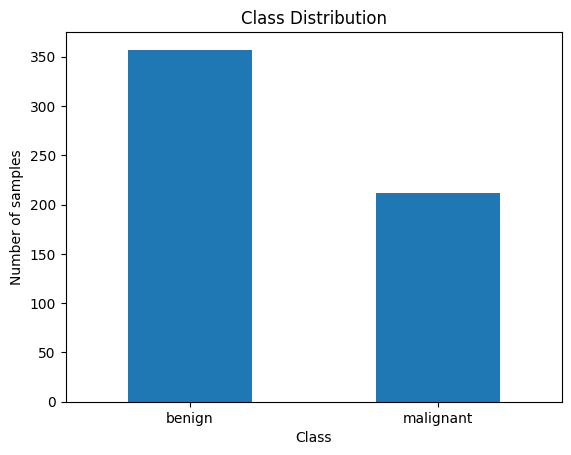

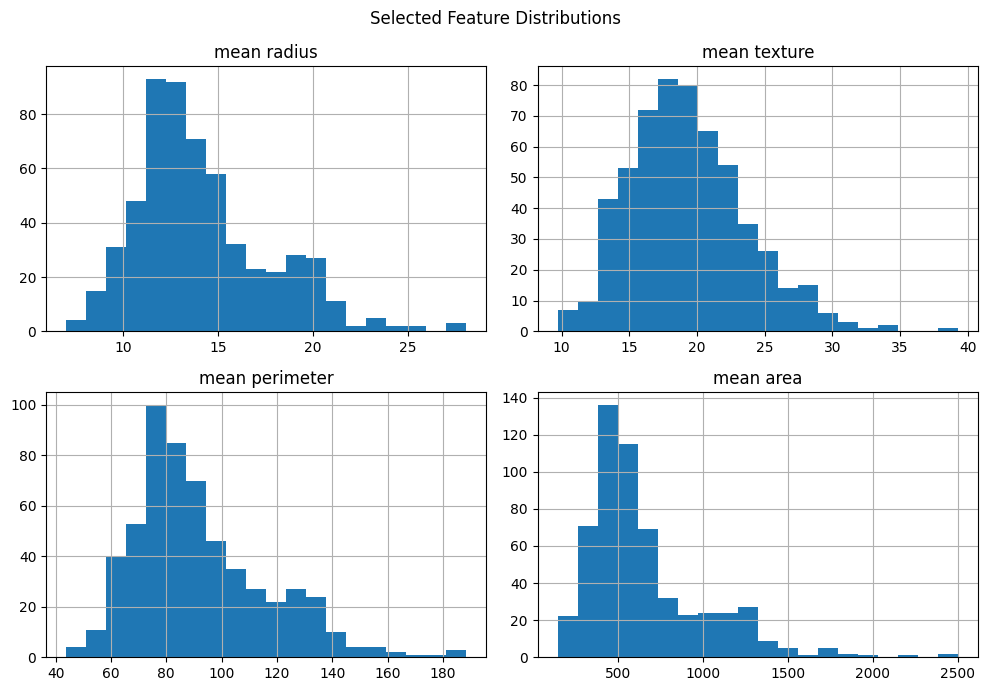

In [5]:
class_counts = df["target_name"].value_counts()
class_counts.plot(kind="bar", title="Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()

selected_features = ["mean radius", "mean texture", "mean perimeter", "mean area"]
df[selected_features].hist(figsize=(10, 7), bins=20)
plt.suptitle("Selected Feature Distributions")
plt.tight_layout()
plt.show()

## 3. Create a leakage-safe train/test split

We use stratification so that the class proportions remain similar in the training and test sets.

**Important:** The test set must remain untouched until final evaluation.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("\nTraining class proportions:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))

Training samples: 455
Test samples: 114

Training class proportions:


,proportion
target,
0,0.373626
1,0.626374


## 4. Build a preprocessing and modeling pipeline

Feature scaling is fitted only on the training data because the scaler is inside the pipeline. This prevents data leakage.

In [7]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=SEED))
])

baseline_pipeline.fit(X_train, y_train)
print("Baseline model trained.")

Baseline model trained.


## 5. Evaluate the baseline

We calculate:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

For this dataset, class `0` is malignant and class `1` is benign. To emphasize malignant-tumor detection, we also calculate metrics treating class `0` as the positive class.

In [8]:
y_pred = baseline_pipeline.predict(X_test)
y_prob_benign = baseline_pipeline.predict_proba(X_test)[:, 1]
y_prob_malignant = baseline_pipeline.predict_proba(X_test)[:, 0]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (benign as positive)": precision_score(y_test, y_pred),
    "Recall (benign as positive)": recall_score(y_test, y_pred),
    "F1 (benign as positive)": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob_benign),
    "Recall for malignant class": recall_score(y_test, y_pred, pos_label=0),
    "Precision for malignant class": precision_score(y_test, y_pred, pos_label=0),
}

metrics_df = pd.DataFrame(metrics.items(), columns=["Metric", "Score"])
display(metrics_df.style.format({"Score": "{:.4f}"}))

print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

,Metric,Score
0,Accuracy,0.9825
1,Precision (benign as positive),0.9861
2,Recall (benign as positive),0.9861
3,F1 (benign as positive),0.9861
4,ROC-AUC,0.9954
5,Recall for malignant class,0.9762
6,Precision for malignant class,0.9762


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



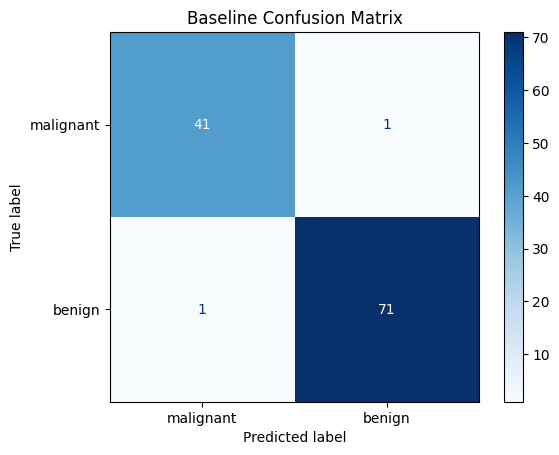

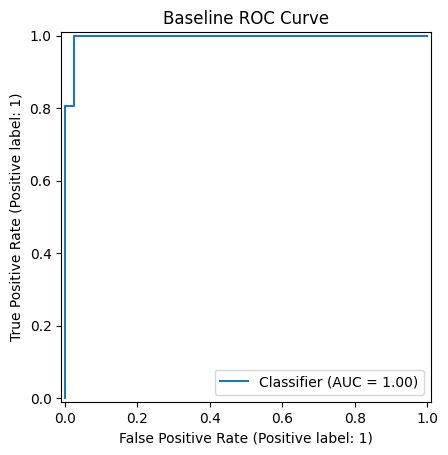

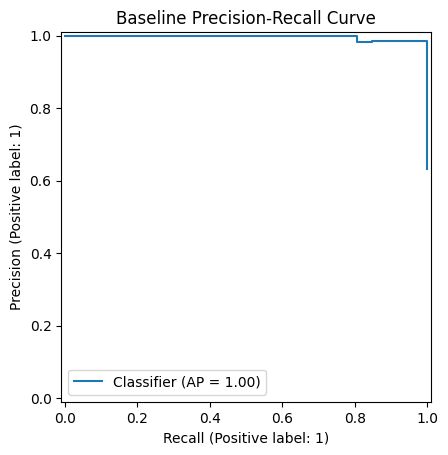

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=data.target_names,
    cmap="Blues"
)
plt.title("Baseline Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob_benign)
plt.title("Baseline ROC Curve")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_prob_benign)
plt.title("Baseline Precision-Recall Curve")
plt.show()

## 6. Perform simple error analysis

Error analysis helps us understand *where* the model fails rather than relying only on aggregate metrics.

In [10]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = y_pred
error_df["probability_benign"] = y_prob_benign
error_df["correct"] = error_df["actual"] == error_df["predicted"]

errors = error_df.loc[~error_df["correct"]].copy()
errors["actual_name"] = errors["actual"].map({0: "malignant", 1: "benign"})
errors["predicted_name"] = errors["predicted"].map({0: "malignant", 1: "benign"})

print("Number of misclassified samples:", len(errors))
display(
    errors[
        ["actual_name", "predicted_name", "probability_benign",
         "mean radius", "mean texture", "mean area"]
    ].sort_values("probability_benign")
)

Number of misclassified samples: 2


,actual_name,predicted_name,probability_benign,mean radius,mean texture,mean area
541,benign,malignant,0.365862,14.47,24.99,656.4
73,malignant,benign,0.908728,13.80,15.79,584.1


## Student activity: Change the decision threshold

The default classification threshold is 0.5. In high-risk applications, we may lower or raise the threshold depending on the cost of false negatives and false positives.

### Task
Try thresholds of `0.30`, `0.40`, `0.50`, `0.60`, and `0.70`. Compare malignant-class recall and precision.

In [11]:
threshold_results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    # Predict benign when P(benign) >= threshold
    threshold_pred = (y_prob_benign >= threshold).astype(int)
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, threshold_pred),
        "malignant_recall": recall_score(y_test, threshold_pred, pos_label=0),
        "malignant_precision": precision_score(y_test, threshold_pred, pos_label=0),
        "f1_macro": f1_score(y_test, threshold_pred, average="macro")
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.style.format({
    "accuracy": "{:.4f}",
    "malignant_recall": "{:.4f}",
    "malignant_precision": "{:.4f}",
    "f1_macro": "{:.4f}"
}))

,threshold,accuracy,malignant_recall,malignant_precision,f1_macro
0,0.300000,0.9825,0.9524,1.0000,0.9810
1,0.400000,0.9825,0.9762,0.9762,0.9812
2,0.500000,0.9825,0.9762,0.9762,0.9812
3,0.600000,0.9561,0.9762,0.9111,0.9535
4,0.700000,0.9474,0.9762,0.8913,0.9445






Proceed to **Notebook 2** for cross-validation, hyperparameter tuning, Random Forest, and XGBoost.